# Spatial disaggregation

Disaggregate raster cells or vector geometries.

**_raster:_** Creates a raster with a higher resolution (smaller cells). The values in the new raster are the same as in the larger original cells.

**_vector:_** Separates multi-objects (points, lines, polygons) into single objects; or further into segments (for lines or polygons).

## Settings

In [1]:
# Load packages
suppressPackageStartupMessages({
  library(terra)
})

# Parameters
param_factor <- 10
param_method <- "bilinear" # or: "near" 
param_out <- tempdir()

# Paths for examples
in_raster <- system.file("ex/elev.tif", package = "terra")
in_vector <- system.file("ex/lux.shp", package = "terra")

## Disaggregate raster

In [7]:
# GSTB disaggregate raster
# NaaVRE:
#  cell:
#   inputs:
#    - in_raster: String
#   params:
#    - param_factor: List
#    - param_method: String
#    - param_out: String
#   outputs:
#    - out: String
#   dependencies:
#    - name: terra
# ...

# Disaggregate raster
disagg(x         = rast(in_raster),
       fact      = param_factor,
       method    = param_method,
       filename  = paste0(param_out, "/disaggregated_raster.tif"),
       overwrite = TRUE)

# Output
out <- list.files(path = param_out,
                  pattern = "disaggregated_raster.tif",
                  full.names = TRUE)

class       : SpatRaster 
dimensions  : 900, 950, 1  (nrow, ncol, nlyr)
resolution  : 0.0008333333, 0.0008333333  (x, y)
extent      : 5.741667, 6.533333, 49.44167, 50.19167  (xmin, xmax, ymin, ymax)
coord. ref. : lon/lat WGS 84 (EPSG:4326) 
source      : disaggregated_raster.tif 
varname     : elev 
name        : elevation 
min value   :    141.05 
max value   :    546.75 

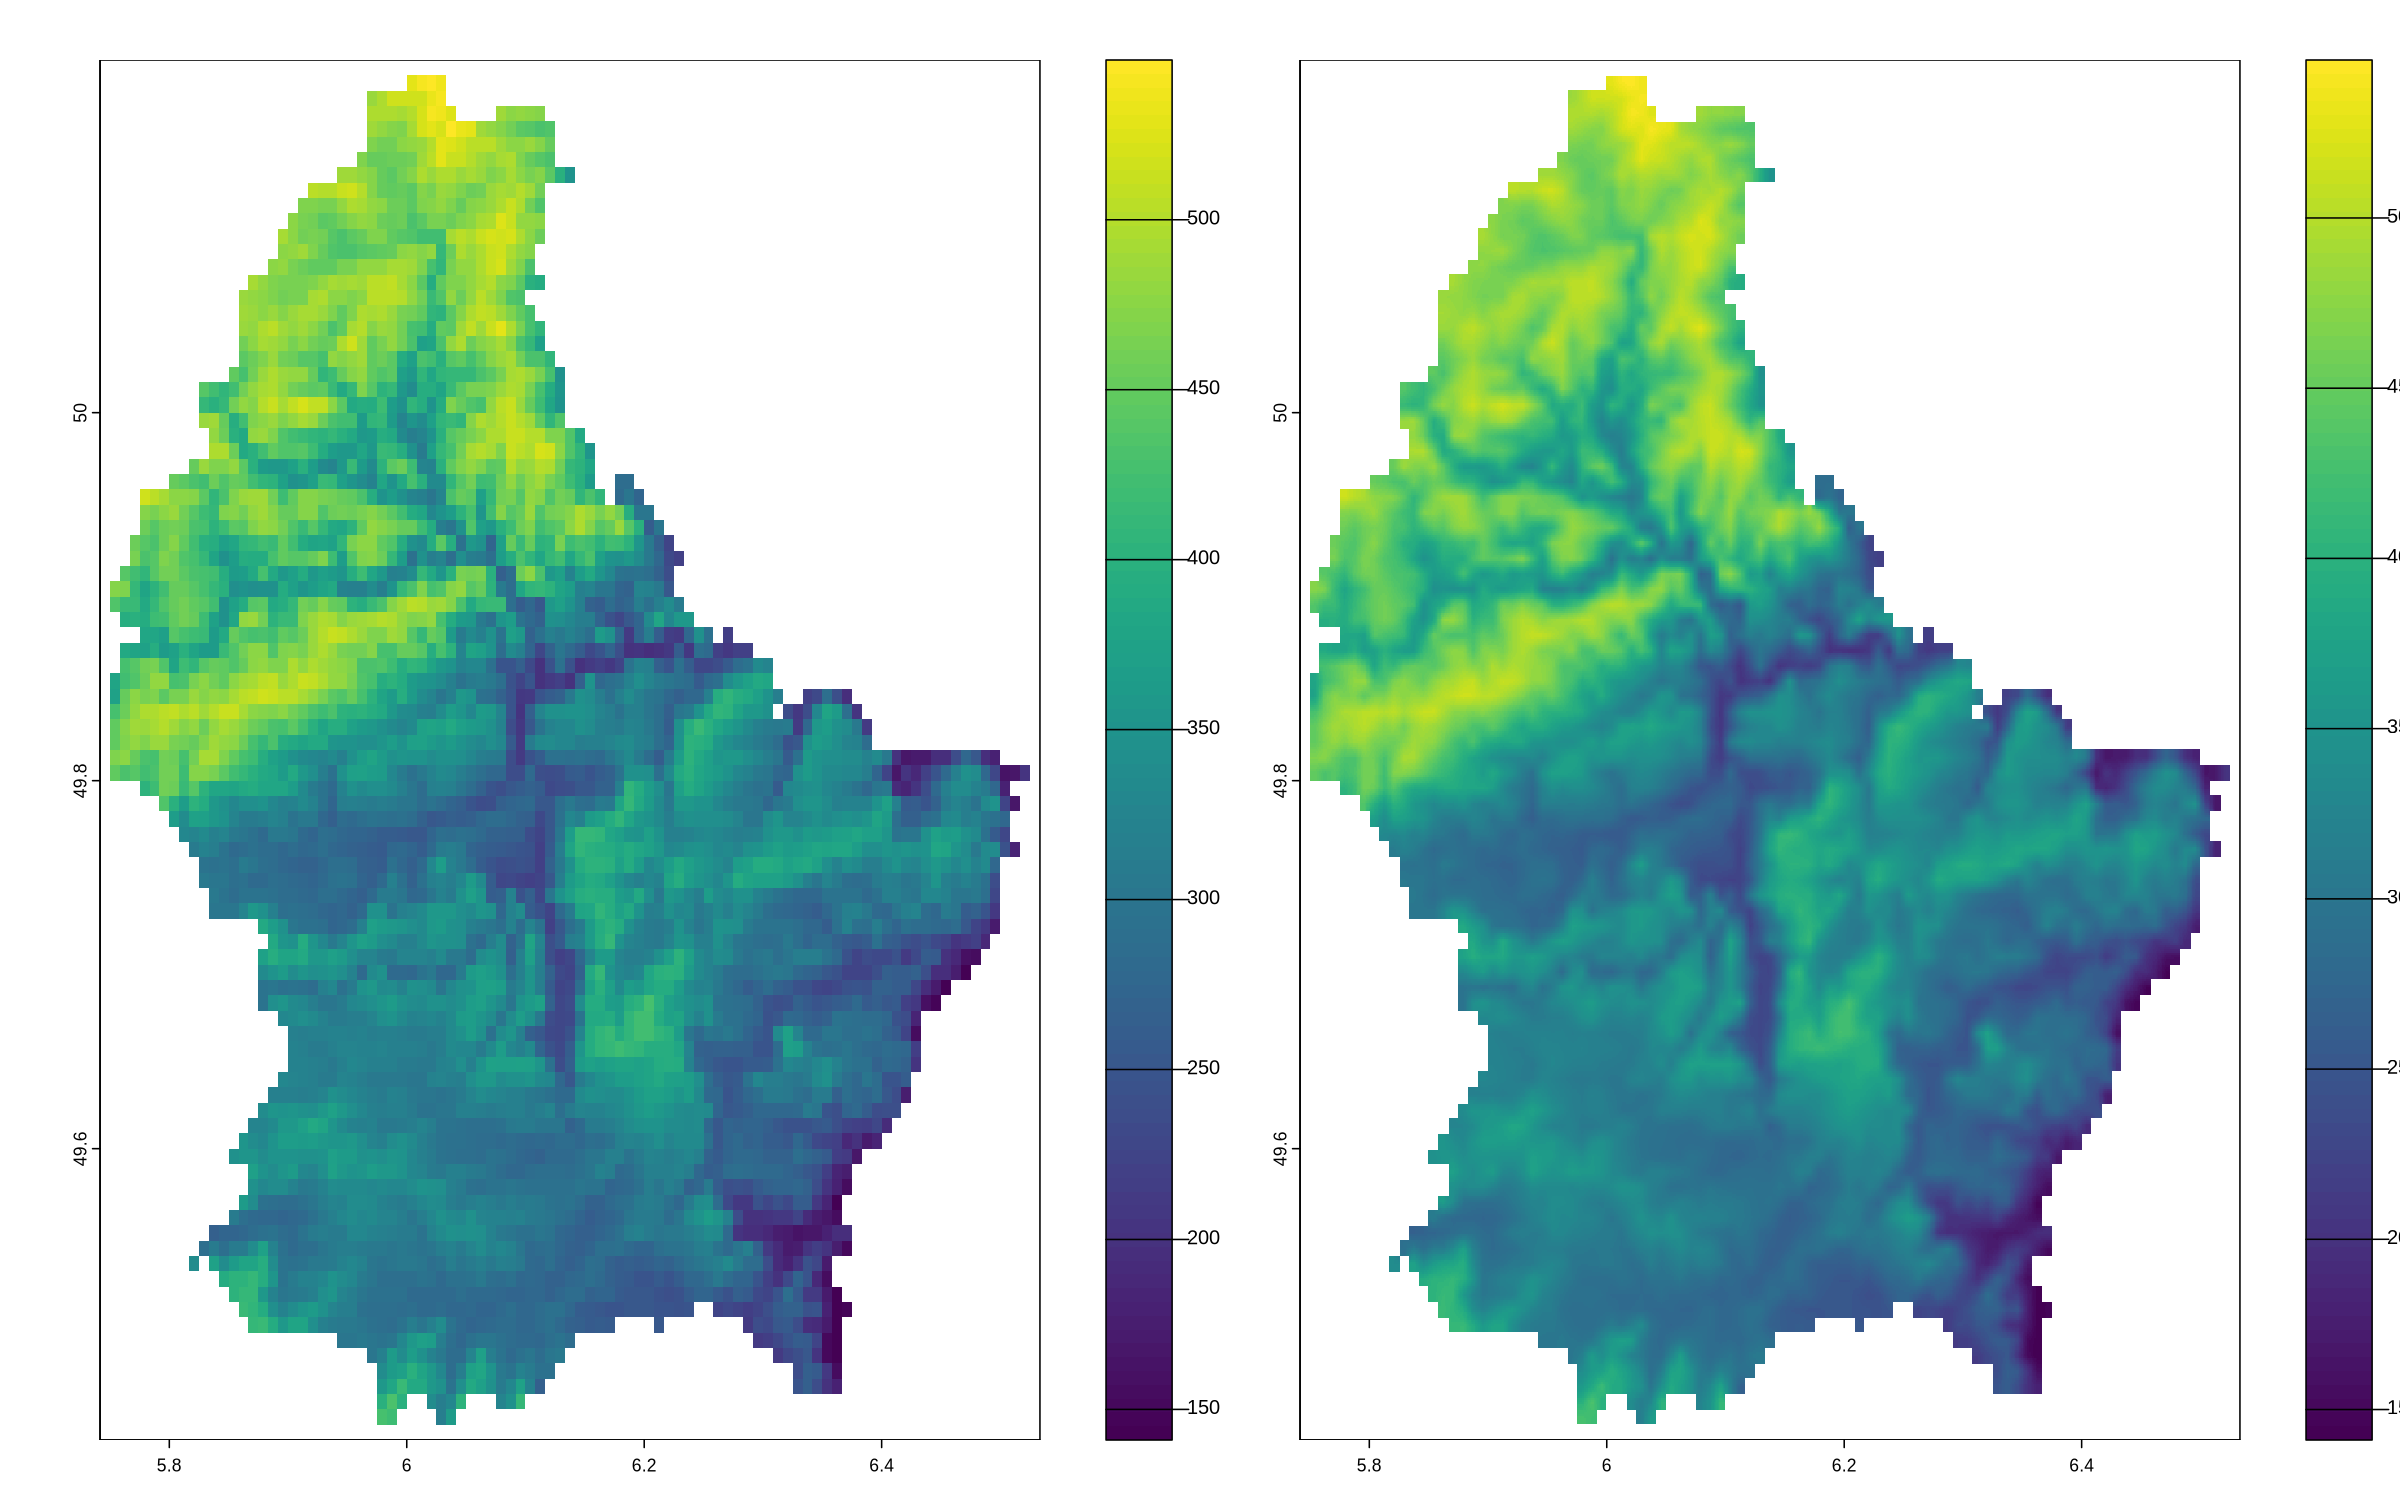

In [8]:
options(repr.plot.width = 16,
        repr.plot.height = 10,
        repr.plot.res = 150)
par(mfrow = c(1, 2))
plot(rast(in_raster))
plot(rast(out))
par(mfrow = c(1, 1))

## Disaggregate vector

In [4]:
# GSTB disaggregate vector
# NaaVRE:
#  cell:
#   inputs:
#    - in_vector: String
#   params:
#    - param_out: String
#   outputs:
#    - out: String
#   dependencies:
#    - name: terra
# ...

# Disaggregate vector
writeVector(x         = disagg(vect(in_vector), segments = FALSE),
            filename  = paste0(param_out, "/disaggregated_vector.gpkg"),
            overwrite = TRUE)

# Output
out <- list.files(path = param_out,
                  pattern = "disaggregated_vector.gpkg",
                  full.names = TRUE)

In [5]:
print(vect(out))

 class       : SpatVector 
 geometry    : polygons 
 dimensions  : 12, 6  (geometries, attributes)
 extent      : 5.74414, 6.528252, 49.44781, 50.18162  (xmin, xmax, ymin, ymax)
 source      : disaggregated_vector.gpkg
 coord. ref. : lon/lat WGS 84 (EPSG:4326) 
 names       :  ID_1   NAME_1  ID_2   NAME_2  AREA       POP
 type        : <num>    <chr> <num>    <chr> <num>     <num>
 values      :     1 Diekirch     1 Clervaux   312 1.808e+04
                   1 Diekirch     2 Diekirch   218 3.254e+04
                   1 Diekirch     3  Redange   259 1.866e+04


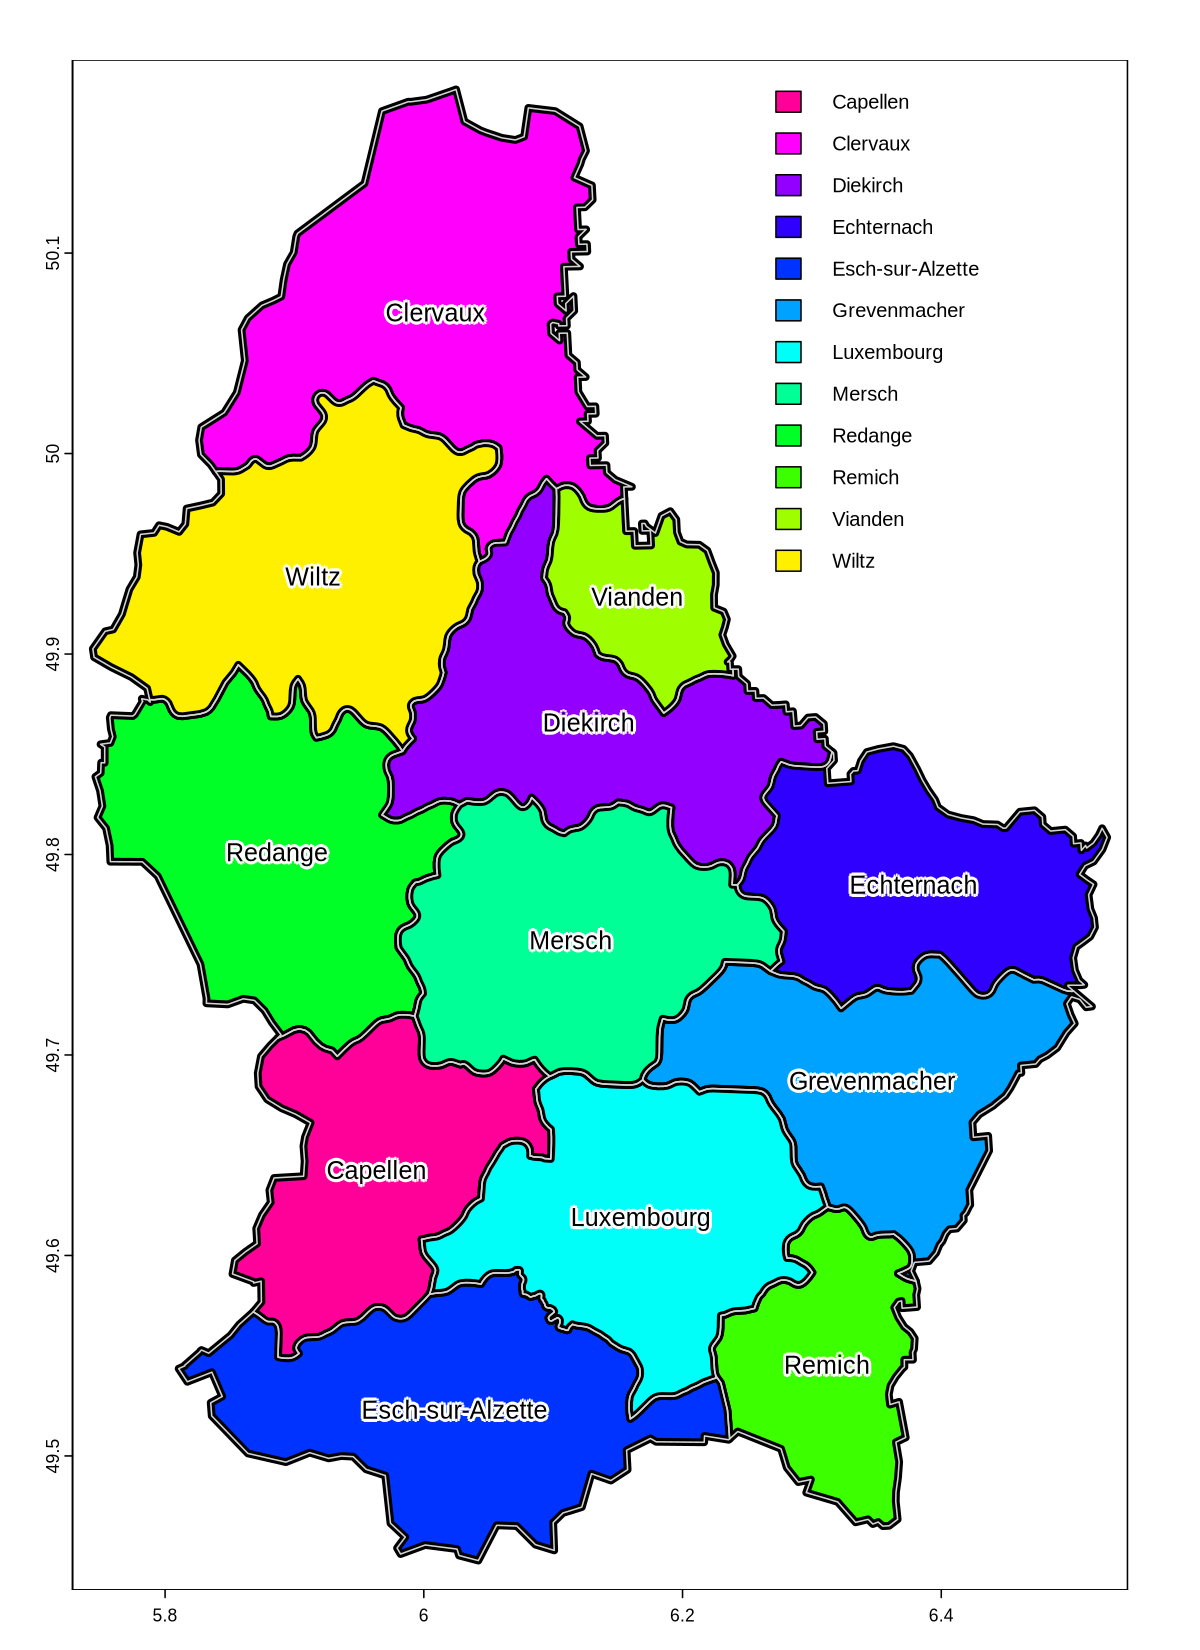

In [6]:
options(repr.plot.width = 8,
        repr.plot.height = 11,
        repr.plot.res = 150)
plot(vect(out), "NAME_2",
     lwd = 5, mar = rep(2, 4),
     plg = list(x = "topright"))
lines(vect(in_vector), lwd = 1, col = "light gray")
text(vect(in_vector), "NAME_2", halo = TRUE)